# Module 4 — Evaluation Metrics under Class Imbalance

## Why you're here: what the model is for
- So far, every model has been graded with one number, AUC: how well it
  **ranks** clients. But the bank doesn't act on a ranking. It acts on a
  **yes/no decision per client**: flag this client as a likely defaulter, or don't.
- The forest gives each client a **score** from 0 to 1. Turning scores into
  yes/no needs a **cut-off**, for example "flag everyone scored 0.3 or above". Different cut-offs flag different clients.
- Two questions then matter: of the clients **flagged**, how many really
  defaulted? And of the clients who **defaulted**, how many were flagged?
- The column is still `default` (1 = the bank recorded the client as
  defaulting in October; the dataset never defines exactly what counts as
  default), and the model is Module 3's forest.

**Your endgame in this module:** pick a cut-off for a stated business goal, read
what it gets right and wrong, and know which single-number grade to trust when
defaulters are rare.

## From the curriculum

> ### <u>Module 4 — Evaluation Metrics under Class Imbalance</u>
>
> **Concepts**
> - Accuracy's trap: predicting "nobody defaults" is right 78% of the time here
>   (because 77.9% of clients paid)
> - Confusion matrix, precision ("of those flagged, how many defaulted?"),
>   recall ("of those who defaulted, how many did we flag?")
> - ROC-AUC vs. PR-AUC (areas under the Receiver Operating Characteristic and
>   Precision-Recall curves), and why a random model's PR-AUC equals the
>   prevalence (the share of defaulters)
> - The cut-off that turns scores into yes/no is a business decision, separate
>   from the model
> - `class_weight` (a setting that makes the model count each defaulter more
>   heavily while learning): what it changes (the ranking of clients barely, the
>   scores a lot, which Module 5 cares about)
>
> **Why it matters**
> Most analyst modelling targets are rare events (fraud, churn, default, a
> security incident). Reporting a metric that looks good regardless of the model's skill is
> the evaluation version of leakage (Module 1: a result that looks good for a
> reason that won't hold in real use).
>
> **Worked example**
> A prevalence sweep: the same model scored on validation sets where defaulters
> are made progressively rarer (by randomly removing some of them), from 22% to
> about 2%. ROC-AUC barely moves, while PR-AUC falls, because precision depends on
> how rare defaulters are. Same model,
> same data: a controlled demonstration of what each metric does and doesn't see.
>
> **Resources**
> - [The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0118432)
>   (Saito & Rehmsmeier, PLOS ONE 2015, open access, verified). Introduction +
>   figures, ~20 min.
>
> **Exercise type:** metric-choice cases: for a given business problem and share
> of defaulters, which metric and cut-off, and why.
>
> **Interview angle:** "Why not use accuracy?" / "ROC-AUC or PR-AUC for fraud?"

## Lesson

### From a score to a yes/no
1. **The score.** For each client, the forest gives a number between 0 and 1: its
   estimate of how likely that client is to default.
2. **The cut-off.** Pick a number. Clients scored at or above it are
   **flagged** (the model says "will default"); the rest are not. The usual
   starting point is 0.5, "flag if default looks more likely than not"; Part 3
   then tries other cut-offs.
3. **Four possible outcomes** for each client, once the real answer is known:

| | really defaulted | really paid |
|---|---|---|
| **flagged** | caught defaulter | false alarm |
| **not flagged** | missed defaulter | correctly left alone |

This 2×2 count is called a **confusion matrix**.

### Precision and recall
- **Precision** = caught defaulters ÷ all flagged clients. *Of the clients we
  flagged, what share really defaulted?* Low precision means many false alarms.
- **Recall** = caught defaulters ÷ all real defaulters. *Of the clients who
  defaulted, what share did we flag?* Low recall means many missed defaulters.
- **The trade-off.** Lowering the cut-off flags more clients: recall goes up
  (fewer missed), precision goes down (more false alarms). Raising it does the
  opposite. No cut-off maximises both; the right one depends on what each
  mistake costs the business.

### Why accuracy misleads here
**Accuracy** is the share of all clients classified correctly. When most clients
pay, a "model" that flags nobody is already right most of the time, while
catching no defaulters at all. Module 1, Part 1 showed this with the bank's phone calls.

### One number for all cut-offs
- **ROC-AUC** (from Module 1): the chance that a random defaulter is scored
  above a random payer. It doesn't depend on any cut-off.
- **PR-AUC** (area under the Precision-Recall curve): trace precision against
  recall across every possible cut-off, and take the area under that curve. It
  summarises how much precision you keep as you push recall up. (scikit-learn
  computes it with `average_precision_score`, its standard estimate of this
  area.)
- **The baseline** is what a model that scores clients at random would get. For
  ROC-AUC, that's always 0.5. For PR-AUC, it's the **share of defaulters**
  (about 22% in this data), because a random flag is right exactly as often as defaulters
  occur. So a PR-AUC is only meaningful next to that share.

### Still not a cause
Everything here grades predictions. Nothing in this module says why clients
default.

### Part 0 — The model and the rows
Module 3's forest (300 trees, each tree's final groups holding at least 50
clients, the 15 prepared columns), fitted on the same 18,000 training rows. Everything below is measured
on the 6,000 **validation rows**, which the forest never saw.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

from common import load_credit, credit_split, prepare_credit

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

train, valid, test = credit_split(load_credit())
X_train, y_train = prepare_credit(train), train["default"]
X_valid, y_valid = prepare_credit(valid), valid["default"].to_numpy()

forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(X_train, y_train)
score = forest.predict_proba(X_valid)[:, 1]          # each validation client's score, 0 to 1

print(f"training rows: {len(X_train):,}   validation rows: {len(y_valid):,}   defaulters in validation: {y_valid.sum():,} ({y_valid.mean():.1%})")
print(f"validation AUC: {roc_auc_score(y_valid, score):.4f}   (Module 3's forest scored 0.7830)")
print(f"scores: lowest {score.min():.3f}, middle half {np.percentile(score, 25):.3f} to {np.percentile(score, 75):.3f}, highest {score.max():.3f}")

training rows: 18,000   validation rows: 6,000   defaulters in validation: 1,327 (22.1%)
validation AUC: 0.7830   (Module 3's forest scored 0.7830)
scores: lowest 0.044, middle half 0.107 to 0.251, highest 0.798


### Part 1 — From scores to yes/no, with the cut-off at 0.5
Four validation clients, one for each possible outcome: their score, what the
cut-off decides, and what really happened:

In [2]:
cut = 0.5
flagged_all = score >= cut
cases = [("caught defaulter", flagged_all & (y_valid == 1)), ("false alarm", flagged_all & (y_valid == 0)),
         ("missed defaulter", ~flagged_all & (y_valid == 1)), ("correctly left alone", ~flagged_all & (y_valid == 0))]
for name, mask in cases:
    i = np.where(mask)[0][0]                           # the first validation client with this outcome
    decision = "flagged" if score[i] >= cut else "not flagged"
    truth = "defaulted" if y_valid[i] == 1 else "paid"
    print(f"client {valid.index[i]:>5}: score {score[i]:.3f} -> {decision:<11}; really {truth:<9} = {name}")

client  6828: score 0.710 -> flagged    ; really defaulted = caught defaulter
client  9647: score 0.521 -> flagged    ; really paid      = false alarm
client 13280: score 0.459 -> not flagged; really defaulted = missed defaulter
client 10314: score 0.261 -> not flagged; really paid      = correctly left alone


In [3]:
def outcome_counts(score, y, cut):
    flagged = score >= cut
    return {"caught defaulters": int((flagged & (y == 1)).sum()),
            "false alarms": int((flagged & (y == 0)).sum()),
            "missed defaulters": int((~flagged & (y == 1)).sum()),
            "correctly left alone": int((~flagged & (y == 0)).sum())}

c = outcome_counts(score, y_valid, 0.5)
print("Confusion matrix, cut-off 0.5 (validation rows):")
print(f"{'':<14}{'really defaulted':>18}{'really paid':>14}")
print(f"{'flagged':<14}{c['caught defaulters']:>18,}{c['false alarms']:>14,}")
print(f"{'not flagged':<14}{c['missed defaulters']:>18,}{c['correctly left alone']:>14,}")

Confusion matrix, cut-off 0.5 (validation rows):
                really defaulted   really paid
flagged                      476           226
not flagged                  851         4,447


### Part 2 — Precision, recall and accuracy at 0.5

In [4]:
flagged = c["caught defaulters"] + c["false alarms"]
defaulters = c["caught defaulters"] + c["missed defaulters"]
precision = c["caught defaulters"] / flagged
recall = c["caught defaulters"] / defaulters
accuracy = (c["caught defaulters"] + c["correctly left alone"]) / len(y_valid)
print(f"precision = caught / flagged    = {c['caught defaulters']} / {flagged} = {precision:.3f}")
print(f"recall    = caught / defaulters = {c['caught defaulters']} / {defaulters:,} = {recall:.3f}")
print(f"accuracy  = right / all clients = ({c['caught defaulters']} + {c['correctly left alone']:,}) / {len(y_valid):,} = {accuracy:.3f}")
print(f"\naccuracy of flagging nobody = payers / all clients = {(y_valid == 0).sum():,} / {len(y_valid):,} = {(y_valid == 0).mean():.3f}")

precision = caught / flagged    = 476 / 702 = 0.678
recall    = caught / defaulters = 476 / 1,327 = 0.359
accuracy  = right / all clients = (476 + 4,447) / 6,000 = 0.821

accuracy of flagging nobody = payers / all clients = 4,673 / 6,000 = 0.779


**Observation:** at the cut-off of 0.5, about two in three flagged clients really
defaulted (precision 0.678), but only about one defaulter in three was flagged
(recall 0.359). Accuracy is 0.821, against 0.779 for flagging nobody.

**Conclusion:** accuracy makes the forest look barely better than doing nothing,
and says nothing about the two-thirds of defaulters it missed. Precision and
recall describe what the bank actually gets from a cut-off.

### Part 3 — Moving the cut-off
The same scores, seven different cut-offs:

 cut-off  clients flagged  precision  recall
     0.1             4749      0.264   0.946
     0.2             2055      0.431   0.668
     0.3             1216      0.559   0.512
     0.4              911      0.628   0.431
     0.5              702      0.678   0.359
     0.6              430      0.723   0.234
     0.7              170      0.788   0.101


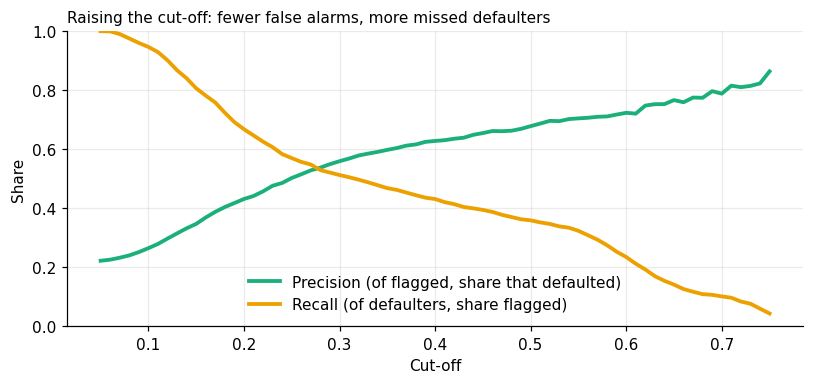

In [5]:
rows = []
for cut in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    c = outcome_counts(score, y_valid, cut)
    f = c["caught defaulters"] + c["false alarms"]
    rows.append({"cut-off": cut, "clients flagged": f,
                 "precision": c["caught defaulters"] / f,
                 "recall": c["caught defaulters"] / y_valid.sum()})
table = pd.DataFrame(rows)
print(table.round(3).to_string(index=False))

grid = np.linspace(0.05, 0.75, 71)
prec = [outcome_counts(score, y_valid, g)["caught defaulters"] / max((score >= g).sum(), 1) for g in grid]
rec = [outcome_counts(score, y_valid, g)["caught defaulters"] / y_valid.sum() for g in grid]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(grid, prec, color=AQUA, linewidth=2.5, label="Precision (of flagged, share that defaulted)")
ax.plot(grid, rec, color="#eda100", linewidth=2.5, label="Recall (of defaulters, share flagged)")
ax.set_xlabel("Cut-off"); ax.set_ylabel("Share"); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower center")
ax.set_title("Raising the cut-off: fewer false alarms, more missed defaulters", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** at a cut-off of 0.1 the forest flags 4,749 of the 6,000 clients
and catches 94.6% of defaulters, but only about one flag in four is right. At 0.7
it flags 170 clients, about four in five right, and catches only 10.1% of
defaulters.

**Conclusion:** the cut-off is a dial, not a property of the model. The forest is
the same in every row; only the business decision changes.

### Part 4 — Choosing a cut-off for a stated goal
Two realistic goals, each picking its own cut-off from the same scores:
- **Goal A, "catch at least half of the defaulters":** the highest cut-off whose
  recall is still at least 0.5 (it flags the fewest clients, so it gives the
  fewest false alarms). Another version targets precision instead: "at least 70%
  of flags must be real defaulters".
- **Goal B, "the collections team can call 500 clients":** flag the 500 highest
  scores. Another version targets caught defaulters instead: "catch 500 real
  defaulters".

All four, on the same scores:

In [6]:
order = np.argsort(-score)                       # validation clients, highest score first
caught_so_far = np.cumsum(y_valid[order])        # defaulters caught if the top n are flagged

def result(n_flagged):
    caught = int(caught_so_far[n_flagged - 1])
    return {"cut-off": round(float(score[order][n_flagged - 1]), 3), "clients flagged": n_flagged,
            "defaulters caught": caught, "precision": caught / n_flagged, "recall": caught / y_valid.sum()}

n = np.arange(1, len(score) + 1)
goals = {
    "A:  recall at least 0.5":            n[caught_so_far / y_valid.sum() >= 0.5].min(),
    "A': precision at least 0.7":         n[caught_so_far / n >= 0.7].max(),
    "B:  flag 500 clients":               500,
    "B': catch 500 real defaulters":      n[caught_so_far >= 500].min(),
}
table = pd.DataFrame([{"goal": goal, **result(int(k))} for goal, k in goals.items()]).round(3)
print(table.to_string(index=False, formatters={"goal": lambda s: s.ljust(31)}, justify="left"))

goal                             cut-off  clients flagged  defaulters caught  precision  recall
A:  recall at least 0.5         0.313    1159             664                0.573      0.500  
A': precision at least 0.7      0.537     635             445                0.701      0.335  
B:  flag 500 clients            0.583     500             358                0.716      0.270  
B': catch 500 real defaulters   0.470     757             500                0.661      0.377  


**Observation:** each goal fixes something different, and gets its own cut-off:
- **A (recall at least 0.5)** needs a low cut-off and accepts that over 40% of
  its flags are false alarms.
- **A' (precision at least 0.7)** needs a high cut-off: few false alarms, but most
  defaulters are missed.
- **B (flag 500)** fixes the number of flags; **B' (catch 500)** fixes the number
  of caught defaulters, which takes a lower cut-off and more flags than 500,
  because some flags are false alarms.

**Conclusion:** the same model serves all four goals. What differs is which
mistake the business prefers to make, and that belongs in the conversation with
the team using the model, not in the model.

### Part 5 — One number for all cut-offs: ROC-AUC vs PR-AUC
The Precision-Recall curve traces precision against recall across every cut-off.
The dashed line is the **baseline**: what a model scoring clients at random would
get, which is the share of defaulters at every level of recall.

ROC-AUC: 0.7830   (random model: 0.5)
PR-AUC:  0.5563   (random model: the share of defaulters, 0.2212)


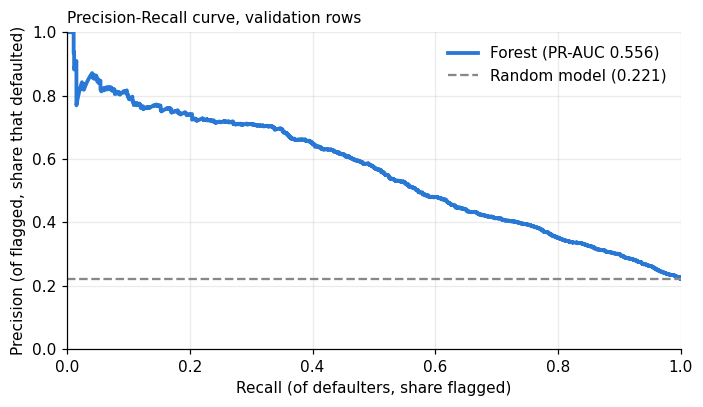

In [7]:
p_curve, r_curve, _ = precision_recall_curve(y_valid, score)
pr_auc = average_precision_score(y_valid, score)
print(f"ROC-AUC: {roc_auc_score(y_valid, score):.4f}   (random model: 0.5)")
print(f"PR-AUC:  {pr_auc:.4f}   (random model: the share of defaulters, {y_valid.mean():.4f})")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(r_curve, p_curve, color=BLUE, linewidth=2.5, label=f"Forest (PR-AUC {pr_auc:.3f})")
ax.axhline(y_valid.mean(), color="#888888", linestyle="--", linewidth=1.5, label=f"Random model ({y_valid.mean():.3f})")
ax.set_xlabel("Recall (of defaulters, share flagged)"); ax.set_ylabel("Precision (of flagged, share that defaulted)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right")
ax.set_title("Precision-Recall curve, validation rows", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** the forest's PR-AUC is about 2.5 times the random baseline. As
recall rises towards 1, precision slides down to the baseline: flagging nearly
everyone means flags are right only as often as defaulters occur.

### Part 6 — When defaulters get rarer
The same forest and the same scores, graded on validation sets where defaulters
are made progressively rarer, by randomly removing some of them and keeping all
payers. Removing defaulters at random makes each grade wobble a little, so each
rarity level is repeated 20 times with different random removals and the grades
are averaged; 20 is enough for a steady average. At each level, the table also
shows precision at the cut-off of 0.5:

 share of defaulters  defaulters kept  ROC-AUC  PR-AUC  PR-AUC ÷ baseline  precision at 0.5
               0.221             1326    0.783   0.556              2.516             0.678
               0.100              519    0.781   0.356              3.557             0.449
               0.050              246    0.782   0.230              4.596             0.280
               0.020               95    0.781   0.124              6.222             0.133
(defaulters kept is rounded from the share, so the 22.1% row keeps 1,326 of the 1,327)


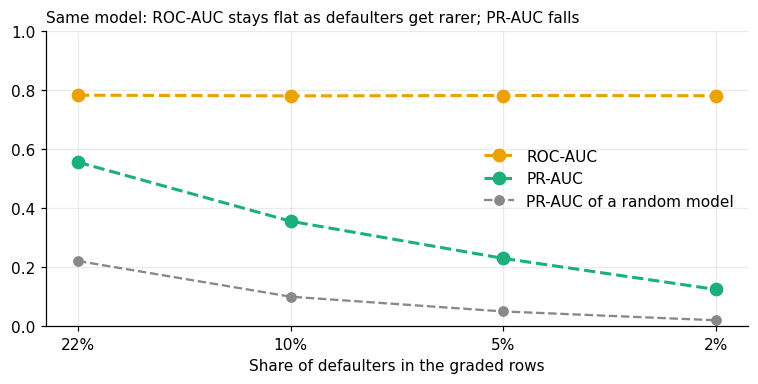

In [8]:
payers = np.where(y_valid == 0)[0]
all_defaulters = np.where(y_valid == 1)[0]
sweep = []
recall_grid = np.linspace(0, 1, 201)
avg_curves = {}
for share in [0.221, 0.10, 0.05, 0.02]:
    n_keep = min(int(round(share * len(payers) / (1 - share))), len(all_defaulters))
    roc, pr, prec5 = [], [], []
    for k in range(20):
        rng_k = np.random.default_rng(k)
        keep = np.r_[payers, rng_k.choice(all_defaulters, n_keep, replace=False)]
        roc.append(roc_auc_score(y_valid[keep], score[keep]))
        pr.append(average_precision_score(y_valid[keep], score[keep]))
        f = score[keep] >= 0.5
        prec5.append(y_valid[keep][f].mean())
        p_k, r_k, _ = precision_recall_curve(y_valid[keep], score[keep])
        curves_k = curves_k + [np.interp(recall_grid, r_k[::-1], p_k[::-1])] if k else [np.interp(recall_grid, r_k[::-1], p_k[::-1])]
    avg_curves[share] = (np.mean(curves_k, axis=0), np.mean(pr))
    sweep.append({"share of defaulters": share, "defaulters kept": n_keep,
                  "ROC-AUC": np.mean(roc), "PR-AUC": np.mean(pr), "PR-AUC ÷ baseline": np.mean(pr) / share,
                  "precision at 0.5": np.mean(prec5)})
sweep = pd.DataFrame(sweep)
print(sweep.round(3).to_string(index=False))
print("(defaulters kept is rounded from the share, so the 22.1% row keeps 1,326 of the 1,327)")

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(sweep))
ax.plot(x, sweep["ROC-AUC"], marker="o", markersize=8, linewidth=2, linestyle="--", color="#eda100", label="ROC-AUC")
ax.plot(x, sweep["PR-AUC"], marker="o", markersize=8, linewidth=2, linestyle="--", color=AQUA, label="PR-AUC")
ax.plot(x, sweep["share of defaulters"], marker="o", markersize=6, linewidth=1.5, linestyle="--", color="#888888", label="PR-AUC of a random model")
ax.set_xticks(x, [f"{s:.0%}" for s in sweep["share of defaulters"]])
ax.set_xlabel("Share of defaulters in the graded rows"); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="center right")
ax.set_title("Same model: ROC-AUC stays flat as defaulters get rarer; PR-AUC falls", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

*Reading the chart: the dots are the four measured levels. The dashed lines only
connect them in order and say nothing about levels in between (the horizontal
axis isn't to scale either).*

**Observation:** ROC-AUC stays at about 0.78 at every rarity level. PR-AUC falls
from about 0.55 to about 0.12. The model didn't change; only how rare defaulters
are.

**Why:** ROC-AUC compares defaulters with payers in pairs, so it doesn't care how
many of each there are. Precision does: a cut-off flags the same share of
defaulters and the same share of payers as before, but payers now make up a much
bigger part of the pool, so more of the flags are payers. At the cut-off of 0.5,
precision falls from about 0.68 to about 0.13 (last column): at 2%, most flags are
false alarms.

**How to read "PR-AUC ÷ baseline":** it rises (from about 2.5 to about 6.2)
because the baseline falls faster than PR-AUC does. It says the model beats random
guessing by more when defaulters are rare, *not* that the flags are more useful;
the flags' actual quality is the plain PR-AUC and the precision column.

**Conclusion:** ROC-AUC alone can make a model look equally useful whether
defaulters are 22% or 2% of clients. For rare events, report PR-AUC and precision
alongside the random baseline.

The same four levels as full Precision-Recall curves, like Part 5's chart. Each
curve is the average of its 20 random removals. The red circle on each curve marks
where it crosses its own PR-AUC, i.e. its average height:

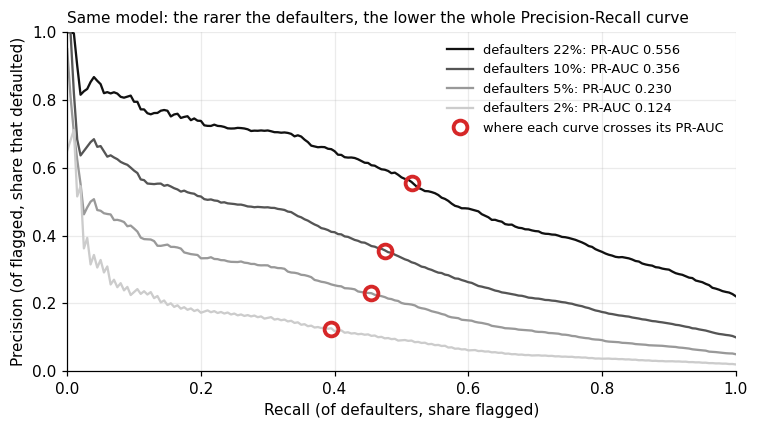

In [9]:
shades = {0.221: "#111111", 0.10: "#555555", 0.05: "#999999", 0.02: "#cccccc"}
fig, ax = plt.subplots(figsize=(7, 4))
for share, (curve, pr_auc_avg) in avg_curves.items():
    ax.plot(recall_grid, curve, color=shades[share], linewidth=1.5,
            label=f"defaulters {share:.0%}: PR-AUC {pr_auc_avg:.3f}")
    cross = recall_grid[np.where(curve >= pr_auc_avg)[0].max()]      # last recall where the curve is still at or above its PR-AUC
    ax.plot(cross, pr_auc_avg, marker="o", markersize=9, markerfacecolor="none", markeredgecolor="#d62728",
            markeredgewidth=2.5, linestyle="none")
ax.plot([], [], marker="o", markersize=9, markerfacecolor="none", markeredgecolor="#d62728", markeredgewidth=2.5,
        linestyle="none", label="where each curve crosses its PR-AUC")
ax.set_xlabel("Recall (of defaulters, share flagged)"); ax.set_ylabel("Precision (of flagged, share that defaulted)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right", fontsize=8.5)
ax.set_title("Same model: the rarer the defaulters, the lower the whole Precision-Recall curve", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** the four curves never cross: at every level of recall, precision
is lower when defaulters are rarer. The black curve (22%) uses the validation rows
as they are, so it's essentially Part 5's curve (one defaulter out of 1,327 drops
out only because of rounding).

**Observation:** the red circles move left as defaulters get rarer. The curve gets
more front-loaded, high only for the first few flags and low for the rest, so it
reaches its own average height at a lower recall.

**Hypothesis:** at extreme rarity, the curve would approach an "L" shape: a spike
at the far left, then nearly flat along the floor.

### Part 7 — `class_weight`: a common reaction, and its side effect
A common reaction to rare defaulters is to tell the model to count each
defaulter more heavily while learning, so it pays them more attention. In
scikit-learn that's `class_weight="balanced"`: here each defaulter counts about
3.5 times as much as each payer (that's 77.9 ÷ 22.1, the ratio of payers to
defaulters).

If scores are honest probabilities, their average should equal the real share of
defaulters: a group of clients each scored P should contain a share P of
defaulters. Two tests follow.

In [10]:
forest_weighted = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0,
                                         class_weight="balanced").fit(X_train, y_train)
score_weighted = forest_weighted.predict_proba(X_valid)[:, 1]
print(f"{'':<22}{'ROC-AUC':>9}{'average score':>15}")
print(f"{'forest':<22}{roc_auc_score(y_valid, score):>9.4f}{score.mean():>15.3f}")
print(f"{'forest, balanced':<22}{roc_auc_score(y_valid, score_weighted):>9.4f}{score_weighted.mean():>15.3f}")
print(f"\nTest 1: balanced forest's average score {score_weighted.mean():.3f} vs real share of defaulters {y_valid.mean():.3f}")

band = (score_weighted >= 0.35) & (score_weighted < 0.45)
print(f"Test 2: clients scored 0.35 to 0.45 by the balanced forest (a band around its average score, "
      f"{score_weighted.mean():.3f}).")
print(f"        honest scores would mean about 35-45% of them defaulted; real defaulter share = {y_valid[band].mean():.1%}")

                        ROC-AUC  average score
forest                   0.7830          0.221
forest, balanced         0.7819          0.430

Test 1: balanced forest's average score 0.430 vs real share of defaulters 0.221
Test 2: clients scored 0.35 to 0.45 by the balanced forest (a band around its average score, 0.430).
        honest scores would mean about 35-45% of them defaulted; real defaulter share = 18.1%


**Observation:** the ranking of clients (their order by score, from most to least
likely to default) barely changes: ROC-AUC 0.7819 against 0.7830. The
two tests:
- **Test 1:** compared the balanced forest's average score (0.430) with the real
  share of defaulters (0.221). **Realized** its scores run about twice too high,
  on average.
- **Test 2:** took the clients scored between 0.35 and 0.45 by the balanced
  forest. That band is centred on 0.4, close to 0.430, its average score, so it
  checks a typical score, and it holds enough clients for a reliable share. If
  the scores were honest, about 35–45% of them would have defaulted; only 18.1%
  did. **Realized** a typical score overstates the real risk about twofold, so
  these scores can't be read as probabilities.

**Conclusion:** `class_weight` doesn't make the model see defaulters better; on
average it pushes scores up, which moves where any given cut-off falls. If scores
are going to be read as probabilities, that has to be corrected. A risk score
must be, because the bank uses the probability itself, for example to estimate
expected losses. That's Module 5.

## Exercises

For each claim below: say what's wrong with it, then rewrite it correctly. The
answer follows each claim.

**(a) "Our model is 82% accurate, so it catches most defaulters."**
Accuracy counts every client, most of whom pay. At the cut-off of 0.5 the forest
catches only about a third of defaulters (Part 2). **Rewrite (Observation):**
"At a cut-off of 0.5 the forest flags 702 clients; about two thirds of them
defaulted (precision 67.8%), and it catches 35.9% of all defaulters (recall)."

**(b) "Precision at cut-off = 0.1 is only 0.26, so a cut-off of 0.1 is bad."**
Not in itself: it's the price of catching 94.6% of defaulters (Part 3). Whether
that's bad depends on the goal. **Rewrite (Conclusion):** "A cut-off of 0.1 suits
a goal of missing almost no defaulters, at the cost of three false alarms for
every caught defaulter."

**(c) "The model's ROC-AUC is 0.78 on a 2% default portfolio too, so it's just as
useful there."**
ROC-AUC ignores how rare defaulters are; PR-AUC falls to about 0.12 at 2%
(Part 6). **Rewrite (Observation):** "The model ranks equally well at 2%, but
most of its flags would be false alarms; PR-AUC is about 0.12 against a random
baseline of 0.02."

**(d) "After `class_weight=balanced`, the model says this client is 60% likely to
default."** (An imaginary client, for the example.)
The balanced forest's scores average about twice the real default rate (Part 7),
so its 0.60 is not a 60% probability. **Rewrite (Observation):** "The balanced
forest ranks this client high; its score can't be read as a probability until it
is corrected (Module 5)."

## Key takeaways

- **Conclusion:** a cut-off turns scores into yes/no decisions. Precision (caught
  defaulters / all flagged clients) and recall (caught defaulters / all real
  defaulters) pull in opposite directions as it moves.
- **Conclusion:** accuracy misleads when most clients pay: 0.821 for the forest at
  cut-off = 0.5 against 0.779 for flagging nobody, while two-thirds of defaulters go missed.
- **Conclusion:** the cut-off is a business decision. The same forest served
  "catch half the defaulters" and "call 500 clients" with different cut-offs.
- **Conclusion:** ROC-AUC stays flat as defaulters get rarer; PR-AUC falls with
  them. For rare events, report PR-AUC next to its random baseline.
- **Conclusion:** `class_weight="balanced"` barely changes the ranking of clients (their order by score; ROC-AUC 0.7819 vs 0.7830) but roughly
  doubles the scores, so they stop reading as probabilities, which is the problem
  Module 5 solves.
- **Conclusion:** everything here grades predictions; none of it says why clients
  default.